
B_R1s(r) =
+14.1889 * exp(-7.0178 r)
+6.6485 * exp(-3.9468 r)
-4.0837 * r^2 * exp(-12.7297 r)
-0.0122 * r^2 * exp(-2.7646 r)
+21.6225 * r * exp(-5.7420 r)
+0.0036 * r * exp(-1.5436 r)
-0.0002 * r * exp(-1.0802 r)

B_R2s(r) =
-0.8384 * exp(-7.0178 r)
+5.0451 * exp(-3.9468 r)
-1.4026 * r^2 * exp(-12.7297 r)
-1.0670 * r^2 * exp(-2.7646 r)
-4.5899 * r * exp(-5.7420 r)
-1.6554 * r * exp(-1.5436 r)
-0.7268 * r * exp(-1.0802 r)

B_R2p(r) =
+0.6932 * r * exp(-5.7416 r)
+0.5869 * r * exp(-2.6341 r)
+0.9689 * r * exp(-1.8340 r)
+0.7070 * r * exp(-1.1919 r)
+0.3323 * r * exp(-0.8494 r)
Norm 1s = 1.0000003554842807
Norm 2s = 1.000000110930777
Norm 2p = 1.0000007814633813
           Q  J_1s_one_electron  J_2s_one_electron  J_2p_one_electron  \
0       0.00       1.859912e-01       9.997698e-01       6.146447e-01   
1       0.05       1.859215e-01       9.900289e-01       6.145694e-01   
2       0.10       1.857127e-01       9.614767e-01       6.139219e-01   
3       0.15       1.853654e-01       9

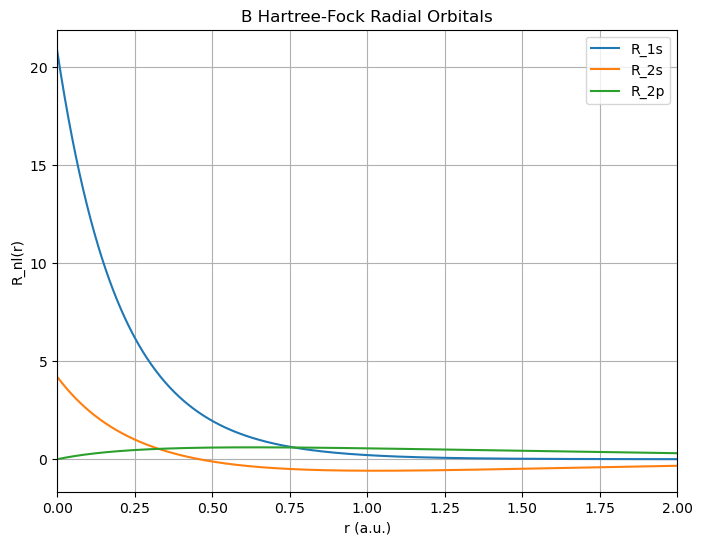

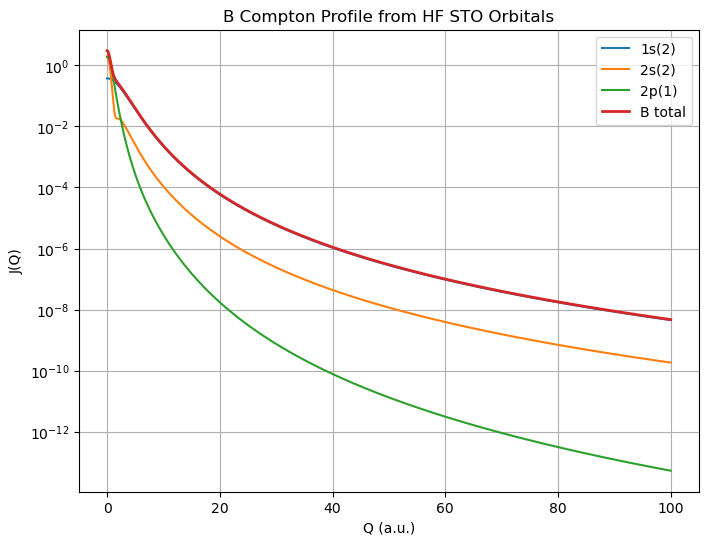

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Boron Hartree-Fock STO data
# B: 1s2 2s2 2p1
# Ground term: 2P
# Format: (n_j, Z_j, C_j)
# =====================================================

boron_1s = [
    (1, 7.0178,  0.381607),
    (1, 3.9468,  0.423958),
    (3, 12.7297, -0.001316),
    (3, 2.7646, -0.000822),
    (2, 5.7420,  0.237016),
    (2, 1.5436,  0.001062),
    (2, 1.0802, -0.000137),
]

boron_2s = [
    (1, 7.0178, -0.022549),
    (1, 3.9468,  0.321716),
    (3, 12.7297, -0.000452),
    (3, 2.7646, -0.072032),
    (2, 5.7420, -0.050313),
    (2, 1.5436, -0.484281),
    (2, 1.0802, -0.518986),
]

boron_2p = [
    (2, 5.7416, 0.007600),
    (2, 2.6341, 0.045137),
    (2, 1.8340, 0.184206),
    (2, 1.1919, 0.394754),
    (2, 0.8494, 0.432795),
]
# =====================================================
# HF normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, boron_1s)
R2s = R_nl(r, boron_2s)
R2p = R_nl(r, boron_2p)

print_R_formula(boron_1s, "B_R1s")
print_R_formula(boron_2s, "B_R2s")

print_R_formula(boron_2p, "B_R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))

# N: 1s2 2s2 2p3
J_total = 2*J_1s + 2*J_2s + 1*J_2p   

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_total_B": J_total
    })
print(table)
table.to_csv("B_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("B Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 3*J_2p, label="2p(1)")
plt.plot(Q, J_total, label="B total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("B Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()